In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


import warnings
warnings.simplefilter("ignore", category=FutureWarning)
warnings.simplefilter("ignore", category=UserWarning)

In [2]:
df = pd.read_csv('/kaggle/input/heart-disease-prediction-using-logistic-regression/framingham.csv')
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 529.9 KB


In [4]:
df.isnull().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

In [5]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='most_frequent')
df['education'] = imputer.fit_transform(df[['education']])

In [6]:
df.isnull().sum()

male                 0
age                  0
education            0
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

In [7]:
smoker_mean = df.loc[df['currentSmoker'] == 1, 'cigsPerDay'].mean()
df.loc[(df['currentSmoker'] == 1) & (df['cigsPerDay'].isnull()), 'cigsPerDay'] = smoker_mean
df.loc[(df['currentSmoker'] == 0) & (df['cigsPerDay'].isnull()), 'cigsPerDay'] = 0.0

In [8]:
df.isnull().sum()

male                 0
age                  0
education            0
currentSmoker        0
cigsPerDay           0
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

In [9]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='most_frequent')
df['BPMeds'] = imputer.fit_transform(df[['BPMeds']])

In [10]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
df['totChol'] = imputer.fit_transform(df[['totChol']])

In [11]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
df['BMI'] = imputer.fit_transform(df[['BMI']])

In [12]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
df['glucose'] = imputer.fit_transform(df[['glucose']])

In [13]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
df['heartRate'] = imputer.fit_transform(df[['heartRate']])

In [14]:
df.isnull().sum()

male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64

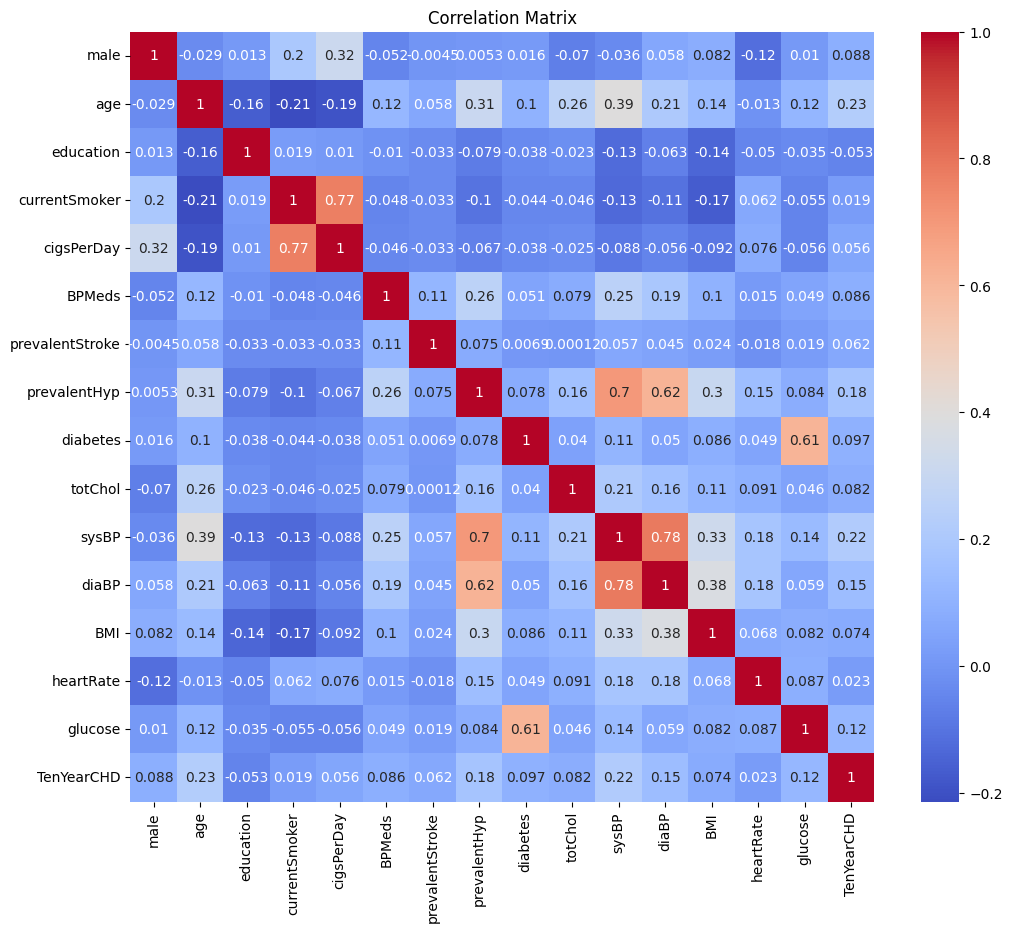

In [15]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

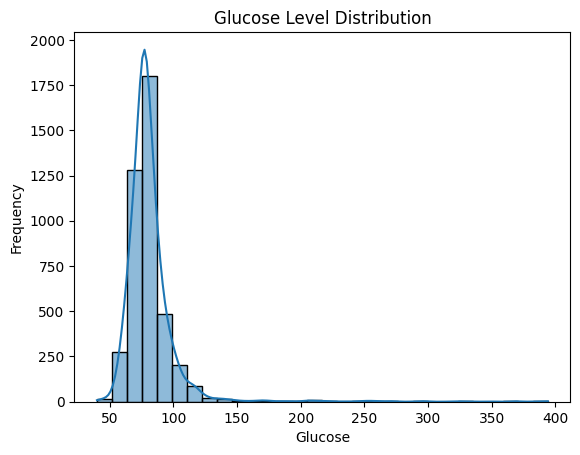

In [16]:
sns.histplot(df["glucose"], kde=True, bins=30)
plt.title("Glucose Level Distribution")
plt.xlabel("Glucose")
plt.ylabel("Frequency")
plt.show()

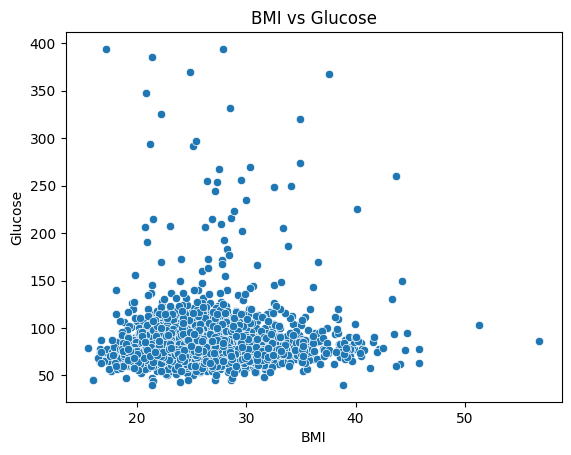

In [17]:
sns.scatterplot(data=df, x="BMI", y="glucose")
plt.title("BMI vs Glucose")
plt.xlabel("BMI")
plt.ylabel("Glucose")
plt.show()

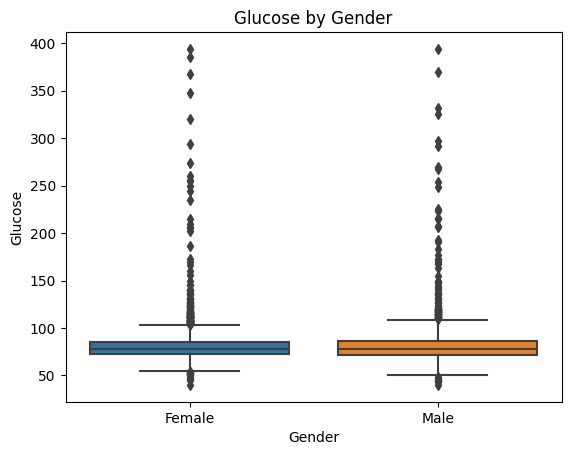

In [18]:
sns.boxplot(data=df, x="male", y="glucose")
plt.title("Glucose by Gender")
plt.xlabel("Gender")
plt.ylabel("Glucose")
plt.xticks([0, 1], ["Female", "Male"])
plt.show()

In [19]:
target = "glucose"
X = df.drop(columns=[target])
y = df[target]

In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

In [21]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [22]:
y_pred = model.predict(X_test)

In [23]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("R² Score:", r2)

Mean Squared Error (MSE): 369.51628291295333
R² Score: 0.342359709849274


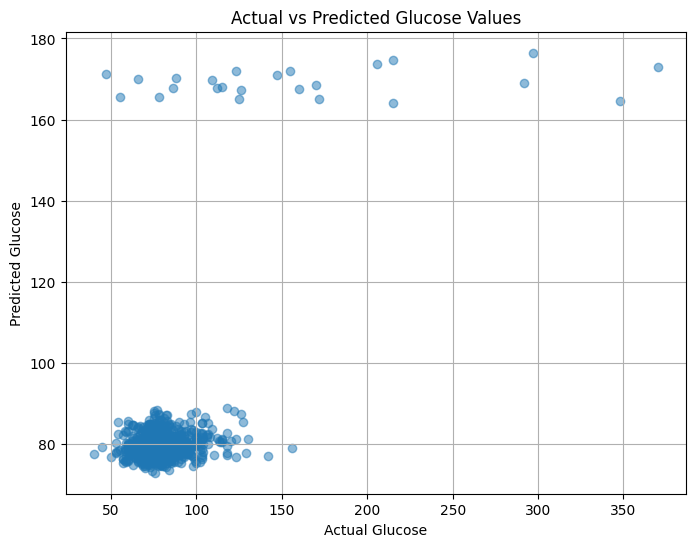

In [24]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Glucose")
plt.ylabel("Predicted Glucose")
plt.title("Actual vs Predicted Glucose Values")
plt.grid(True)
plt.show()

In [25]:
from sklearn.tree import DecisionTreeRegressor
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [26]:
y_pred_dt = dt_model.predict(X_test)

In [27]:
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree MSE:", mse_dt)
print("Decision Tree R² Score:", r2_dt)

Decision Tree MSE: 848.9433962264151
Decision Tree R² Score: -0.5108925025298561


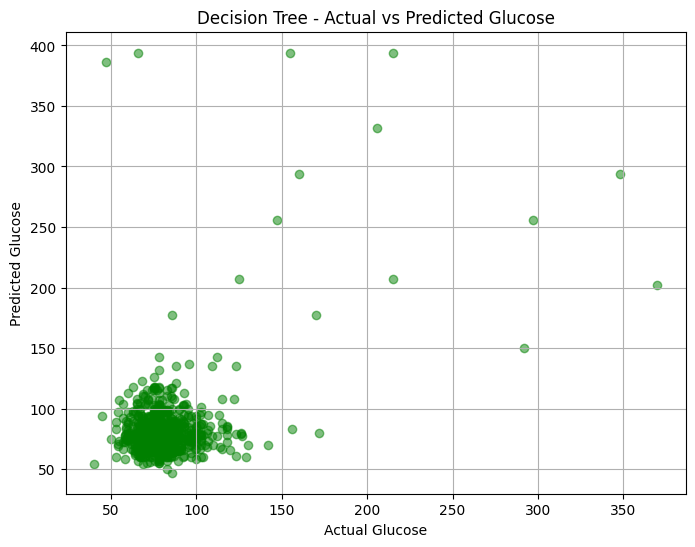

In [28]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_dt, alpha=0.5, color="green")
plt.xlabel("Actual Glucose")
plt.ylabel("Predicted Glucose")
plt.title("Decision Tree - Actual vs Predicted Glucose")
plt.grid(True)
plt.show()

In [29]:
print("Tree Depth:", dt_model.get_depth())
print("Number of Leaves:", dt_model.get_n_leaves())

Tree Depth: 31
Number of Leaves: 3029


In [30]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree"],
    "MSE": [mse, mse_dt],
    "R²": [r2, r2_dt]
})
results

,Model,MSE,R²
0,Linear Regression,369.516283,0.342360
1,Decision Tree,848.943396,-0.510893


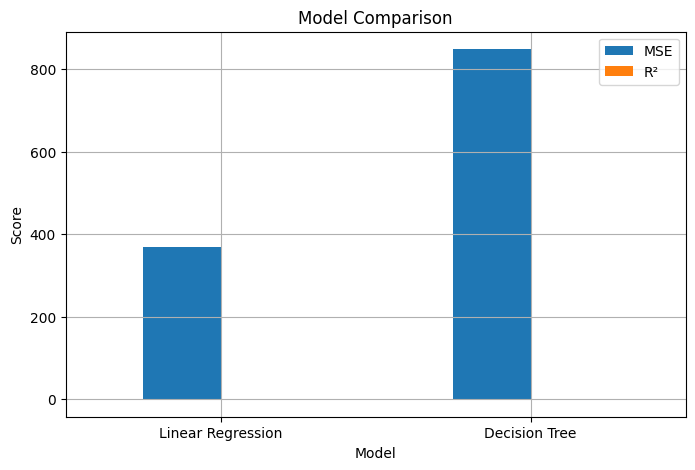

In [31]:
results.set_index("Model").plot(kind="bar", figsize=(8,5), title="Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(True)
plt.show()

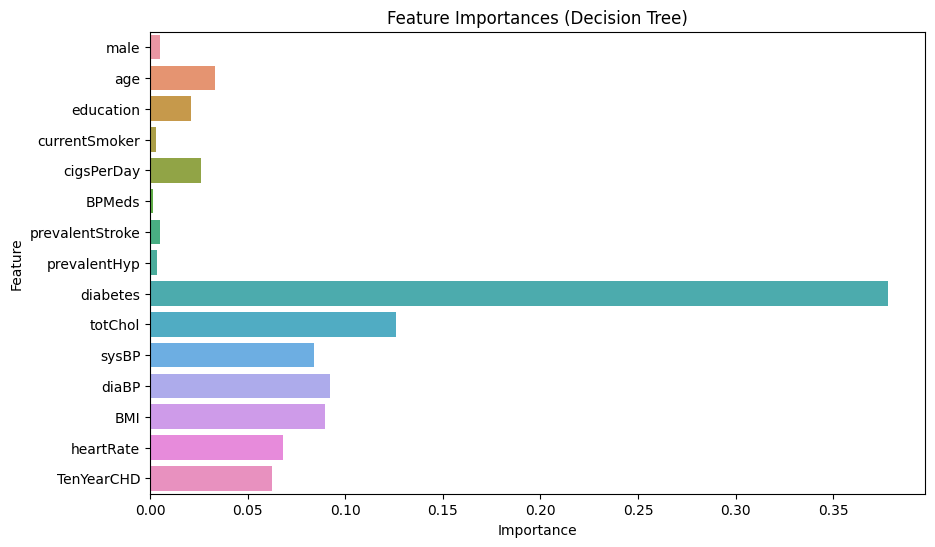

In [32]:
importances = dt_model.feature_importances_
features = X.columns

plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=features)
plt.title("Feature Importances (Decision Tree)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()